<a href="https://colab.research.google.com/github/GAnu1712/AI-ML-Training/blob/main/ObjectDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#download coco class names
!wget https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names

--2024-12-03 10:45:52--  https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 625 [text/plain]
Saving to: ‘coco.names’

coco.names          100%[===================>]     625  --.-KB/s    in 0s      

2024-12-03 10:45:52 (16.9 MB/s) - ‘coco.names’ saved [625/625]



In [ ]:
#Download Yolov3 configuration
!wget https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg

--2024-12-03 10:51:27--  https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8342 (8.1K) [text/plain]
Saving to: ‘yolov3.cfg’

yolov3.cfg          100%[===================>]   8.15K  --.-KB/s    in 0s      

2024-12-03 10:51:27 (75.4 MB/s) - ‘yolov3.cfg’ saved [8342/8342]



In [ ]:
#Download YOLOv3 weights
!wget https://pjreddie.com/media/files/yolov3.weights

--2024-12-03 10:54:56--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 162.0.215.52
Connecting to pjreddie.com (pjreddie.com)|162.0.215.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248007048 (237M) [application/octet-stream]
Saving to: ‘yolov3.weights’

yolov3.weights      100%[===================>] 236.52M  33.6MB/s    in 7.3s    

2024-12-03 10:55:08 (32.4 MB/s) - ‘yolov3.weights’ saved [248007048/248007048]



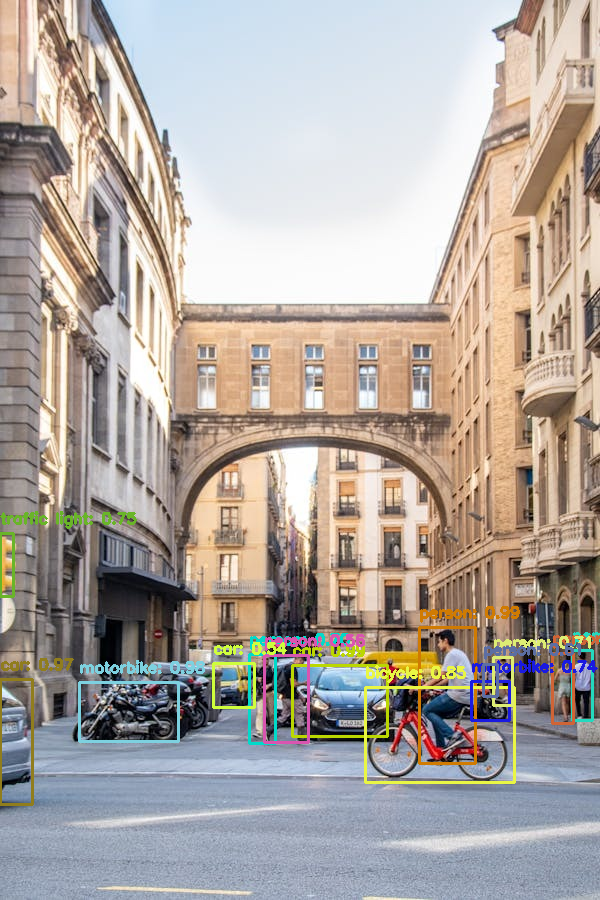

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load YOLO
weights_path = "yolov3.weights"
config_path = "yolov3.cfg"
names_path = "coco.names"

# Load class labels
with open(names_path, "r") as f:
    classes = [line.strip() for line in f.readlines()]

# Load the YOLO network
net = cv2.dnn.readNet(weights_path, config_path)
layer_names = net.getUnconnectedOutLayersNames()

# Load the image
image = cv2.imread("/content/object_detect.jpg")
height, width = image.shape[:2]

# Preprocess the image
blob = cv2.dnn.blobFromImage(image, 1 / 255.0, (416, 416), swapRB=True, crop=False)
net.setInput(blob)
outputs = net.forward(layer_names)

# Process detections
boxes, confidences, class_ids = [], [], []
for output in outputs:
    for detection in output:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]
        if confidence > 0.5:
            center_x, center_y, w, h = (detection[0:4] * np.array([width, height, width, height])).astype("int")
            x = int(center_x - w / 2)
            y = int(center_y - h / 2)
            boxes.append([x, y, int(w), int(h)])
            confidences.append(float(confidence))
            class_ids.append(class_id)

# Apply Non-Maximum Suppression
indices = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)

# Draw bounding boxes
for i in indices.flatten():
    x, y, w, h = boxes[i]
    label = f"{classes[class_ids[i]]}: {confidences[i]:.2f}"
    color = [int(c) for c in np.random.uniform(0, 255, size=3)]
    cv2.rectangle(image, (x, y), (x + w, y + h), color, 2)
    cv2.putText(image, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

# Display the result
cv2_imshow(image)


In [ ]:
# Install PySpark
# !pip install pyspark

# Import Libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, isnan, when, count

# Create Spark Session
spark = SparkSession.builder.appName("TitanicDataAnalysis").getOrCreate()

# Load Dataset (Replace with your file path or upload to Colab)
from google.colab import files
files.upload()  # Upload 'titanic.csv'
df = spark.read.csv("titanic.csv", header=True, inferSchema=True)

# Basic Data Exploration
print("Schema:")
df.printSchema()
print(f"Total Rows: {df.count()}")
df.show(5)

# Count Missing Data
print("Missing Data:")
df.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in df.columns]).show()

# Data Cleaning
df = df.na.fill({"Age": 30, "Embarked": "S"}).withColumn("Age", col("Age").cast("float")).withColumn("Fare", col("Fare").cast("float"))

# Analysis: Survival Rate
print("Survival Rate:")
df.groupBy("Survived").count().show()

# Survival Rate by Gender
print("Survival Rate by Gender:")
df.groupBy("Sex", "Survived").count().show()

# Average Fare by Passenger Class
print("Average Fare by Pclass:")
df.groupBy("Pclass").avg("Fare").show()

# Correlation Between Age and Fare
print(f"Correlation between Age and Fare: {df.stat.corr('Age', 'Fare')}")

# Top 5 Most Expensive Tickets
print("Top 5 Most Expensive Tickets:")
df.orderBy(col("Fare").desc()).show(5)

# Save Processed Data
df.write.csv("processed_titanic_data.csv", header=True)
print("Processed data saved!")


Saving titanic.csv to titanic.csv
Schema:
root
 |-- PassengerId: integer (nullable = true)
 |-- Survived: integer (nullable = true)
 |-- Pclass: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Sex: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- SibSp: integer (nullable = true)
 |-- Parch: integer (nullable = true)
 |-- Ticket: string (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Cabin: string (nullable = true)
 |-- Embarked: string (nullable = true)

Total Rows: 891
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|PassengerId|Survived|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|   Fare|Cabin|Embarked|
+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+
|          1|       0|     3|Braund, Mr. Owen ...|  male|22.0|    1|    0|       A/5 21171|   7.25| NULL|       S|
|          2|      

In [ ]:
df.groupBy("Pclass", "Survived").count().show()

# Survival Rate by Age Group
df = df.withColumn("Age_Group", when(col("Age") < 18, "Child").when((col("Age") >= 18) & (col("Age") <= 60), "Adult").otherwise("Senior"))
df.groupBy("Age_Group", "Survived").count().show()

# Survival Rate by Embarked Port
df.groupBy("Embarked", "Survived").count().show()

# Gender vs Survival
df.groupBy("Sex", "Survived").count().show()

# Average Age and Fare by Survival Status
df.groupBy("Survived").avg("Age", "Fare").show()

# Correlation Between Age and Fare
print(f"Correlation between Age and Fare: {df.stat.corr('Age', 'Fare')}")

# Top 5 Most Expensive Tickets
df.orderBy(col("Fare").desc()).show(5)

+------+--------+-----+
|Pclass|Survived|count|
+------+--------+-----+
|     1|       0|   80|
|     3|       1|  119|
|     1|       1|  136|
|     2|       1|   87|
|     2|       0|   97|
|     3|       0|  372|
+------+--------+-----+

+---------+--------+-----+
|Age_Group|Survived|count|
+---------+--------+-----+
|    Adult|       0|  480|
|    Adult|       1|  276|
|   Senior|       0|   17|
|   Senior|       1|    5|
|    Child|       1|   61|
|    Child|       0|   52|
+---------+--------+-----+

+--------+--------+-----+
|Embarked|Survived|count|
+--------+--------+-----+
|       Q|       1|   30|
|       S|       0|  427|
|       S|       1|  219|
|       C|       1|   93|
|       Q|       0|   47|
|       C|       0|   75|
+--------+--------+-----+

+------+--------+-----+
|   Sex|Survived|count|
+------+--------+-----+
|  male|       0|  468|
|female|       1|  233|
|female|       0|   81|
|  male|       1|  109|
+------+--------+-----+

+--------+------------------+-----